---
**强化学习论 (Reinforcement Learning for LLMs)**

**类目：** 强化学习

**难易：** 中等至深 | **所需时辰：** 约一时辰

---

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy
from collections import Counter
from mp_tutorial.fonts import configure_cjk_fonts
configure_cjk_fonts()

from mp_tutorial.viz import (
    draw_training_pipeline, draw_rlhf_architecture,
    draw_rl_algorithm_comparison, draw_rl_gpu_placement,
    draw_ppo_clip, draw_group_ranking, draw_progressive_models,
    draw_method_timeline,
)
from mp_tutorial.formatting import (
    info_box, comparison_table, code_reference, formula_breakdown,
)
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)

torch.manual_seed(42)
print("Ready!")

Ready!


## 概论

### 大语言模型训练三阶

造一可用之大语言模型，需经三阶。前二阶，诸君于先前篇章已知之：

1. **预训练（Pre-training）** — 于海量文本上预测下一词元（习得语言）
2. **有监督微调（SFT）** — 以人工示范训练（习得遵从指令）
3. **强化学习对齐（RL Alignment）** — 依人之*偏好*而优化（习得人之所欲）

本篇所论者，乃**第三阶**：以强化学习之术，使能而未齐之模型化为合乎人意之器。

### 何以有监督微调不足

有监督微调者，教模型*摹仿*示范也，然：
- 不能为天下之问皆备示范
- 摹仿不能辨「可」与「善」之别
- 模型不知回答中*何者*为要

强化学习解此困局，使模型**尝试而后从反馈中学** —— 「此答优于彼答」。

### 先修之识

- PyTorch 基础（`nn.Module`、优化器、损失函数）
- 推荐先读：[01 — 数据并行](01-data-parallelism.ipynb)

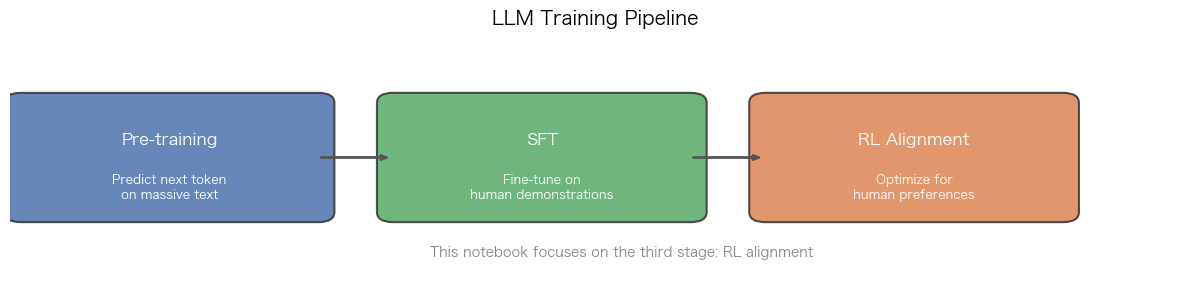

In [2]:
fig, ax = draw_training_pipeline()
plt.show()

## 基石

未入具体算法之前，先筑三要义：
1. **策略（Policy）** — 模型之行为也
2. **奖赏（Reward）** — 评判其行为之优劣
3. **策略梯度（Policy Gradient）** — 以奖赏改进策略之法

### 微型模型：五词语言模型

为使强化学习之理可触可观，本篇通用一微型语言模型。其词表仅五词，生成序列长三。

> **何以如此小？** 五词长三，则全部序列不过一百二十五。吾等可尽观模型所学。此理直推至 GPT 规模之模型——唯大小异耳。

In [3]:
# ── Our tiny language model ──
VOCAB = ["I", "love", "cats", "hate", "dogs"]
V = len(VOCAB)
SEQ_LEN = 3

def decode(token_ids):
    """Convert token indices to words."""
    return " ".join(VOCAB[t] for t in token_ids.tolist())


class TinyLM(nn.Module):
    """A minimal autoregressive language model.

    Given a sequence of tokens, predicts the next token at each position.
    This is exactly what GPT does — just with 5 words instead of 50,000.
    """
    def __init__(self, vocab_size=V, embed_dim=8, hidden_dim=16):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.head = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        """Forward pass (teacher-forced): returns logits at every position."""
        e = self.embed(x)
        h, _ = self.rnn(e)
        return self.head(h)  # (batch, seq_len, vocab_size)

    def log_probs_of(self, sequences):
        """Compute log P(sequence) under the current policy.

        Sums log-probabilities of tokens at positions 1, 2, ..., T-1
        (position 0 is the fixed start token).
        """
        logits = self.forward(sequences)           # (B, T, V)
        dist = torch.distributions.Categorical(logits=logits[:, :-1, :])
        per_token = dist.log_prob(sequences[:, 1:])  # (B, T-1)
        return per_token.sum(dim=1)                   # (B,)

    @torch.no_grad()
    def generate(self, batch_size, seq_len=SEQ_LEN):
        """Generate sequences autoregressively (always starts with 'I')."""
        tokens = [torch.zeros(batch_size, 1, dtype=torch.long)]
        for _ in range(seq_len - 1):
            inp = torch.cat(tokens, dim=1)
            logits = self.forward(inp)[:, -1, :]
            token = torch.distributions.Categorical(logits=logits).sample()
            tokens.append(token.unsqueeze(1))
        return torch.cat(tokens, dim=1)


def reward_fn(sequences):
    """Score sequences: +1 for 'I love cats', penalize 'hate'.

    This is our stand-in for human preferences.
    In real RLHF, a learned reward model replaces this function.
    """
    rewards = []
    for seq in sequences:
        words = [VOCAB[t] for t in seq.tolist()]
        r = 0.0
        if "love" in words and "cats" in words:
            r = 1.0
        elif "love" in words:
            r = 0.3
        if "hate" in words:
            r -= 0.5
        rewards.append(r)
    return torch.tensor(rewards)


# Quick test
model = TinyLM()
seqs = model.generate(8)
for seq in seqs:
    print(f"  {decode(seq):20s}  reward = {reward_fn(seq.unsqueeze(0)).item():+.1f}")

  I I I                 reward = +0.0
  I cats love           reward = +1.0
  I cats dogs           reward = +0.0
  I cats hate           reward = -0.5
  I love I              reward = +0.3
  I hate dogs           reward = -0.5
  I hate love           reward = -0.2
  I dogs I              reward = +0.0


### 策略梯度：核心之理

强化学习用于语言模型，其根本洞见如下：

> **增高奖赏之序列之概率，降低奖薄之序列之概率。**

要旨尽于此矣。PPO、DPO、GRPO 者，皆此理之精炼也。

以数学言之，**REINFORCE** 算法曰：

$$\nabla J(\theta) = \mathbb{E}\left[ R \cdot \nabla \log \pi_\theta(\text{sequence}) \right]$$

逐项解之：

In [4]:
formula_breakdown([
    (
        "π_θ(sequence) — the probability the model<br>assigns to this sequence",
        "π<sub>θ</sub>(a₁, a₂, … | s)",
        "probs = model(sequence).softmax(-1)",
    ),
    (
        "log π_θ — take the log (easier to optimize,<br>"
        "turns products into sums)",
        "log π<sub>θ</sub> = Σ log P(aₜ | a₁..ₜ₋₁)",
        "log_probs = model.log_probs_of(sequence)",
    ),
    (
        "R — the reward score for this sequence<br>"
        "(how good was it?)",
        "R(sequence)",
        "reward = reward_fn(sequence)",
    ),
    (
        "R · ∇log π_θ — push the model toward<br>"
        "high-reward sequences",
        "R · ∇ log π<sub>θ</sub>",
        "loss = -(reward * log_probs).mean()",
    ),
], title="REINFORCE — Term by Term")

In Plain English,Math,PyTorch
π_θ(sequence) — the probability the modelassigns to this sequence,"πθ(a₁, a₂, … | s)",probs = model(sequence).softmax(-1)
"log π_θ — take the log (easier to optimize,turns products into sums)",log πθ = Σ log P(aₜ | a₁..ₜ₋₁),log_probs = model.log_probs_of(sequence)
R — the reward score for this sequence(how good was it?),R(sequence),reward = reward_fn(sequence)
R · ∇log π_θ — push the model towardhigh-reward sequences,R · ∇ log πθ,loss = -(reward * log_probs).mean()


In [5]:
# ── Train with REINFORCE ──
torch.manual_seed(42)
policy = TinyLM()
optimizer = torch.optim.Adam(policy.parameters(), lr=5e-3)
reward_history = []

for step in range(300):
    seqs = policy.generate(batch_size=64)
    rewards = reward_fn(seqs)

    # REINFORCE with baseline (subtract mean to reduce variance)
    baseline = rewards.mean()
    advantages = rewards - baseline

    log_probs = policy.log_probs_of(seqs)
    loss = -(log_probs * advantages).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    reward_history.append(rewards.mean().item())
    if step % 60 == 0:
        print(f"Step {step:3d}  avg reward = {rewards.mean():.3f}")

print(f"\nFinal avg reward: {reward_history[-1]:.3f}")

Step   0  avg reward = -0.059
Step  60  avg reward = 0.905
Step 120  avg reward = 1.000
Step 180  avg reward = 0.984
Step 240  avg reward = 1.000



Final avg reward: 1.000


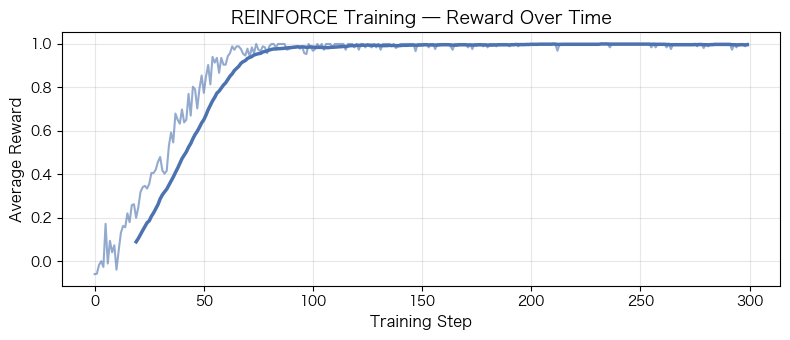

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(reward_history, color="#4C72B0", lw=1.5, alpha=0.6)
# Smoothed
window = 20
smoothed = np.convolve(reward_history, np.ones(window)/window, mode="valid")
ax.plot(range(window-1, len(reward_history)), smoothed, color="#4C72B0", lw=2.5)
ax.set_xlabel("Training Step", fontsize=11)
ax.set_ylabel("Average Reward", fontsize=11)
ax.set_title("REINFORCE Training — Reward Over Time", fontsize=13, fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

info_box(
    "REINFORCE works! The model learns to generate higher-reward sequences. "
    "But look at the <b>variance</b> (noise) in the curve — this is a known "
    "problem with vanilla policy gradients. PPO fixes this.",
    title="Observation"
)

In [7]:
# What did the model learn to generate?
print("Most common sequences after REINFORCE training:\n")
seqs = policy.generate(500)
counts = Counter(decode(s) for s in seqs)
for text, count in counts.most_common(8):
    r = reward_fn(torch.tensor([[VOCAB.index(w) for w in text.split()]])).item()
    print(f"  {text:20s}  freq={count/500:.0%}  reward={r:+.1f}")

Most common sequences after REINFORCE training:

  I cats love           freq=79%  reward=+1.0
  I love cats           freq=20%  reward=+1.0
  I love love           freq=0%  reward=+0.3


## PPO：近端策略优化

REINFORCE 有二弊：
1. **方差甚大** — 训练信号噪杂（前图曲线之锯齿可见）
2. **无护栏** — 一次劣更新足以毁模型所学

PPO 兼解此二弊。吾等逐步构建之，每步添一要件。

### 渐至四模型

真正之 RLHF（PPO 用于大语言模型）需**四模型同驻显存**。闻之骇然，故吾等逐一添之——各解一具体之难。

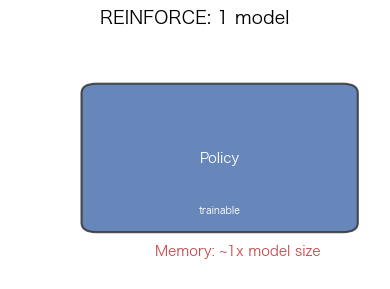

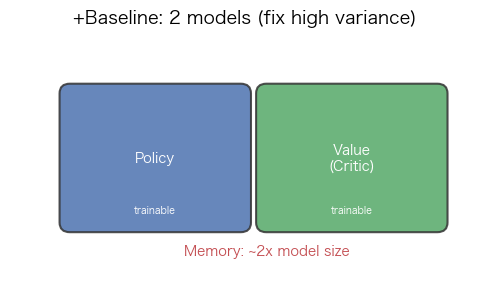

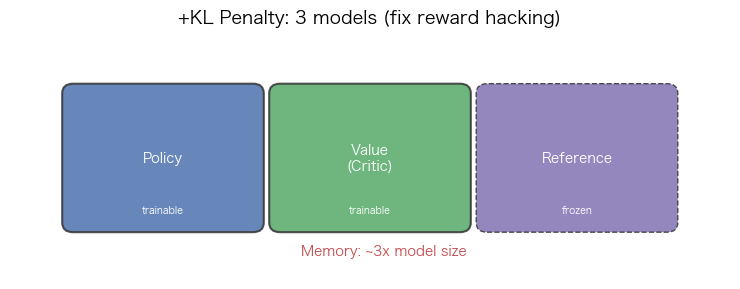

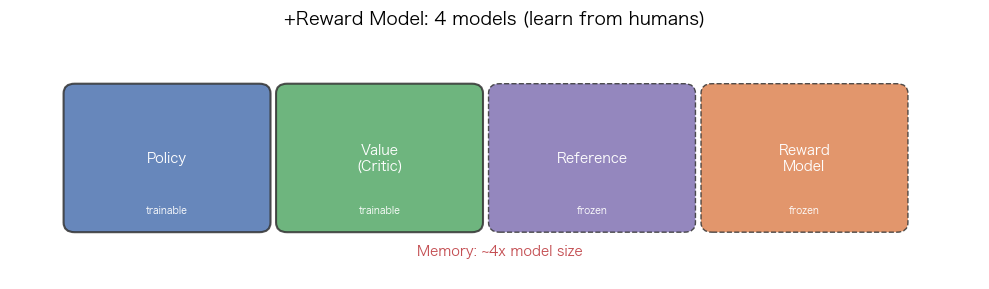

In [8]:
# Draw each stage
for stage in range(1, 5):
    fig_s, ax_s = draw_progressive_models(stage=stage)
    plt.show()

### PPO 裁剪之巧

PPO 之要旨：**不令策略一步变化过巨**。

其法乃算一*概率比*：

$$r(\theta) = \frac{\pi_\text{new}(\text{action})}{\pi_\text{old}(\text{action})}$$

- 若 $r = 1$：新策略与旧策略行为无异
- 若 $r = 2$：新策略取此行动之概率倍于旧
- 若 $r = 0.5$：新策略取此行动之概率减半

PPO 将此比**裁剪**于 $[1-\varepsilon, 1+\varepsilon]$（通常 $\varepsilon = 0.2$），以防剧变：

$$L^{\text{CLIP}} = \min\left( r(\theta) \cdot A, \; \text{clip}(r(\theta), 1-\varepsilon, 1+\varepsilon) \cdot A \right)$$

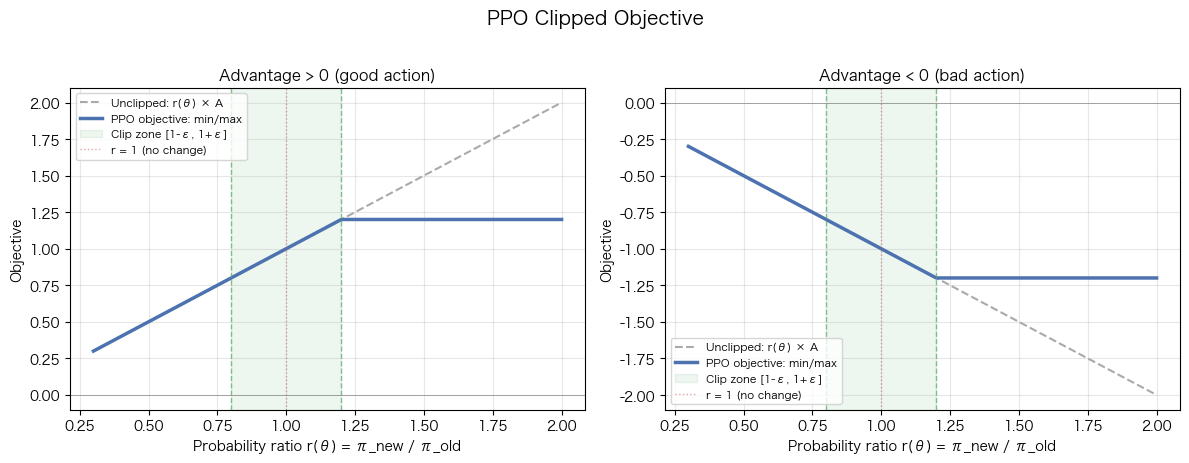

In [9]:
fig, axes = draw_ppo_clip(eps=0.2)
plt.show()

info_box(
    "<b>Left:</b> When the advantage is positive (good action), PPO lets the ratio "
    "increase up to 1+ε but no further — preventing overcommitment.<br>"
    "<b>Right:</b> When the advantage is negative (bad action), PPO lets the ratio "
    "decrease down to 1-ε — the model moves away, but not too aggressively.",
    title="Reading the PPO Clip Plot"
)

In [10]:
formula_breakdown([
    (
        "Probability ratio — how much did the<br>"
        "policy change for this action?",
        "r(θ) = π<sub>new</sub>(a|s) / π<sub>old</sub>(a|s)",
        "ratio = (new_lp - old_lp).exp()",
    ),
    (
        "Clip the ratio — prevent drastic changes",
        "clip(r, 1-ε, 1+ε)",
        "clipped = torch.clamp(ratio, 1-eps, 1+eps)",
    ),
    (
        "Take the conservative option —<br>"
        "min for good actions, prevents overconfidence",
        "min(r·A, clip(r)·A)",
        "loss = -torch.min(ratio*adv, clipped*adv).mean()",
    ),
    (
        "KL penalty — don't drift too far from<br>"
        "the original (reference) model",
        "β · KL(π<sub>θ</sub> ‖ π<sub>ref</sub>)",
        "kl = (new_lp - ref_lp).mean()",
    ),
], title="PPO Loss — Term by Term")

In Plain English,Math,PyTorch
Probability ratio — how much did thepolicy change for this action?,r(θ) = πnew(a|s) / πold(a|s),ratio = (new_lp - old_lp).exp()
Clip the ratio — prevent drastic changes,"clip(r, 1-ε, 1+ε)","clipped = torch.clamp(ratio, 1-eps, 1+eps)"
"Take the conservative option —min for good actions, prevents overconfidence","min(r·A, clip(r)·A)","loss = -torch.min(ratio*adv, clipped*adv).mean()"
KL penalty — don't drift too far fromthe original (reference) model,β · KL(πθ ‖ πref),kl = (new_lp - ref_lp).mean()


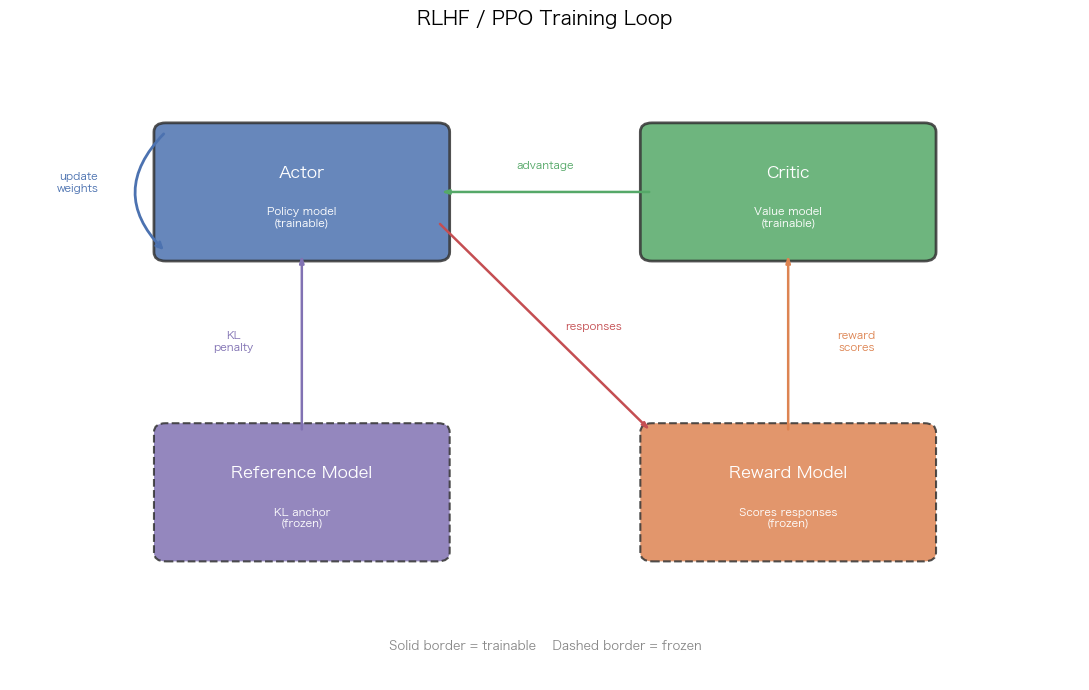

In [11]:
fig, ax = draw_rlhf_architecture()
plt.show()

In [12]:
# ── Train with PPO ──
torch.manual_seed(42)
policy = TinyLM()
ref_model = deepcopy(policy)  # Frozen reference
for p in ref_model.parameters():
    p.requires_grad = False

optimizer = torch.optim.Adam(policy.parameters(), lr=3e-3)
eps_clip = 0.2
kl_coeff = 0.15
reward_hist, kl_hist = [], []

for epoch in range(80):
    # 1. Collect data with current policy
    seqs = policy.generate(batch_size=128)
    rewards = reward_fn(seqs)
    with torch.no_grad():
        old_lp = policy.log_probs_of(seqs)
        ref_lp = ref_model.log_probs_of(seqs)

    advantages = rewards - rewards.mean()

    # 2. Multiple update steps on same batch (PPO's key feature)
    for _ in range(4):
        new_lp = policy.log_probs_of(seqs)
        ratio = (new_lp - old_lp).exp()

        surr1 = ratio * advantages
        surr2 = torch.clamp(ratio, 1 - eps_clip, 1 + eps_clip) * advantages
        ppo_loss = -torch.min(surr1, surr2).mean()

        kl = (new_lp - ref_lp).mean()
        loss = ppo_loss + kl_coeff * kl

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    reward_hist.append(rewards.mean().item())
    kl_hist.append(kl.item())
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}  reward={rewards.mean():.3f}  KL={kl.item():.3f}")

Epoch   0  reward=-0.055  KL=-0.004
Epoch  20  reward=0.898  KL=2.429
Epoch  40  reward=1.000  KL=3.049
Epoch  60  reward=0.989  KL=2.902


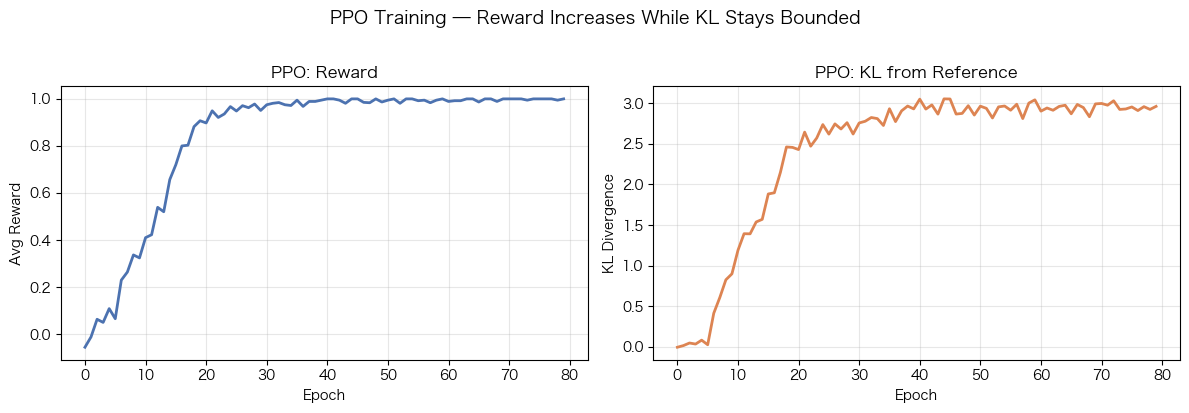

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(reward_hist, color="#4C72B0", lw=2)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Avg Reward")
ax1.set_title("PPO: Reward", fontweight="bold")
ax1.grid(alpha=0.3)

ax2.plot(kl_hist, color="#DD8452", lw=2)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("KL Divergence")
ax2.set_title("PPO: KL from Reference", fontweight="bold")
ax2.grid(alpha=0.3)

plt.suptitle("PPO Training — Reward Increases While KL Stays Bounded",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

info_box(
    "Notice: reward goes up (model improves) while KL stays bounded "
    "(model doesn't drift too far from the reference). This is the "
    "PPO + KL penalty working together — <b>stable improvement</b>.",
    title="PPO vs REINFORCE"
)

## DPO：直接偏好优化

PPO 虽效，然其繁也：四模型、多阶训练、奖赏模型之训练、超参敏感。

**DPO 之洞见**（Rafailov 等，2023）：可径去奖赏模型。

### 数学之捷径

带 KL 惩罚之强化学习目标有闭式最优策略：

$$\pi^*(a|s) = \frac{1}{Z(s)} \pi_{\text{ref}}(a|s) \cdot \exp\left(\frac{1}{\beta} r(a, s)\right)$$

移项之，可以策略表奖赏：

$$r(a, s) = \beta \log \frac{\pi^*(a|s)}{\pi_{\text{ref}}(a|s)} + \text{const}$$

代入 Bradley-Terry 偏好模型而化简之：

$$L_{\text{DPO}} = -\log \sigma\left( \beta \left[ \log \frac{\pi_\theta(y_w)}{\pi_{\text{ref}}(y_w)} - \log \frac{\pi_\theta(y_l)}{\pi_{\text{ref}}(y_l)} \right] \right)$$

白话释之：**使模型更倾于生成人所好之输出（$y_w$），而远人所恶之输出（$y_l$），皆相对于参考模型而言。**

In [14]:
formula_breakdown([
    (
        "Log-ratio for preferred output —<br>"
        "how much more likely is it under our model<br>"
        "vs the reference?",
        "log π<sub>θ</sub>(y<sub>w</sub>) − log π<sub>ref</sub>(y<sub>w</sub>)",
        "lp_w = policy.log_probs_of(preferred) - ref.log_probs_of(preferred)",
    ),
    (
        "Log-ratio for rejected output —<br>"
        "same comparison for the bad response",
        "log π<sub>θ</sub>(y<sub>l</sub>) − log π<sub>ref</sub>(y<sub>l</sub>)",
        "lp_l = policy.log_probs_of(rejected) - ref.log_probs_of(rejected)",
    ),
    (
        "DPO loss — push the gap apart,<br>"
        "making preferred more likely",
        "−log σ(β · (lp_w − lp_l))",
        "loss = -F.logsigmoid(beta * (lp_w - lp_l)).mean()",
    ),
], title="DPO Loss — Term by Term")

In Plain English,Math,PyTorch
Log-ratio for preferred output —how much more likely is it under our modelvs the reference?,log πθ(yw) − log πref(yw),lp_w = policy.log_probs_of(preferred) - ref.log_probs_of(preferred)
Log-ratio for rejected output —same comparison for the bad response,log πθ(yl) − log πref(yl),lp_l = policy.log_probs_of(rejected) - ref.log_probs_of(rejected)
"DPO loss — push the gap apart,making preferred more likely",−log σ(β · (lp_w − lp_l)),loss = -F.logsigmoid(beta * (lp_w - lp_l)).mean()


In [15]:
# ── Train with DPO ──
# Step 1: Create preference pairs
# (In real RLHF, these come from human annotators)
torch.manual_seed(42)

n_pairs = 500
preferred, rejected = [], []
for _ in range(n_pairs):
    # Preferred: sequences with "love"
    good = [[0, 1, 2], [0, 1, 4], [2, 1, 0]][np.random.randint(3)]  # I love cats, etc.
    bad  = [[0, 3, 2], [0, 3, 4], [3, 4, 0]][np.random.randint(3)]  # I hate cats, etc.
    preferred.append(good)
    rejected.append(bad)
preferred = torch.tensor(preferred)
rejected = torch.tensor(rejected)

print(f"Preference dataset: {n_pairs} pairs")
print(f"  Example preferred: {decode(preferred[0])}")
print(f"  Example rejected:  {decode(rejected[0])}")

# Step 2: Train
policy = TinyLM()
ref_model = deepcopy(policy)
for p in ref_model.parameters():
    p.requires_grad = False

optimizer = torch.optim.Adam(policy.parameters(), lr=5e-3)
beta = 0.1
dpo_losses = []

for step in range(300):
    idx = torch.randint(n_pairs, (64,))
    pref_batch = preferred[idx]
    rej_batch = rejected[idx]

    # DPO loss (just 3 lines!)
    lp_w = policy.log_probs_of(pref_batch) - ref_model.log_probs_of(pref_batch)
    lp_l = policy.log_probs_of(rej_batch) - ref_model.log_probs_of(rej_batch)
    loss = -F.logsigmoid(beta * (lp_w - lp_l)).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    dpo_losses.append(loss.item())
    if step % 60 == 0:
        print(f"Step {step:3d}  loss = {loss.item():.4f}")

# Check what the DPO-trained model generates
print("\nAfter DPO training:")
seqs = policy.generate(200)
counts = Counter(decode(s) for s in seqs)
for text, count in counts.most_common(5):
    print(f"  {text:20s}  freq={count/200:.0%}")

Preference dataset: 500 pairs
  Example preferred: I love cats
  Example rejected:  hate dogs I
Step   0  loss = 0.6931
Step  60  loss = 0.1284
Step 120  loss = 0.0381


Step 180  loss = 0.0216
Step 240  loss = 0.0140

After DPO training:
  I love cats           freq=50%
  I love dogs           freq=42%
  I love I              freq=6%
  I love hate           freq=2%


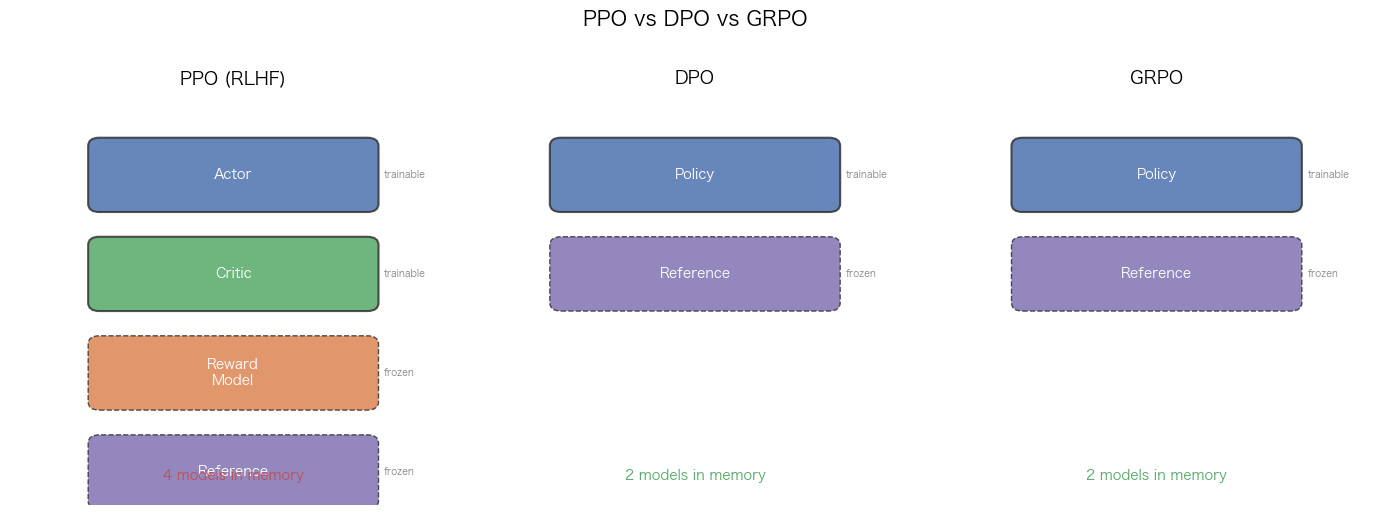

In [16]:
fig, axes = draw_rl_algorithm_comparison()
plt.show()

info_box(
    "DPO reduces the system from <b>4 models to 2</b> — policy + reference. "
    "No reward model to train, no value function to estimate, no "
    "multi-phase training loop. The core idea: optimize preferences "
    "<b>directly</b> instead of going through a reward model.",
    title="DPO's Simplification"
)

## GRPO：群组相对策略优化

DPO 去奖赏模型而简化 RLHF。**GRPO**（DeepSeek-R1 所用）更进一步，兼去**评论模型（critic）**。

### 要旨：群组采样

不另训模型以估「此状态优劣几何」（评论模型之职），GRPO 之法如下：

1. 对每一提示，以当前策略**生成一群 G 个输出**
2. 以奖赏函数（或验证器）**评分**每一输出
3. 算优势为：**较群组均值优劣几何？**

$$A_i = \frac{r_i - \text{mean}(r_1, ..., r_G)}{\text{std}(r_1, ..., r_G)}$$

此即**群组相对优势** —— 无需评论模型！

> **何以可行？** 若生成足够多之输出（G=8 或更多），群组均值即为期望奖赏之合理估计。高于均值者为「优于常」（正优势），低者为「劣于常」（负优势）。法虽简，然 DeepSeek-R1 用之足矣。

Group of 8 generated sequences:
  I I I                 reward = +0.00
  I cats love           reward = +1.00
  I cats dogs           reward = +0.00
  I cats hate           reward = -0.50
  I love I              reward = +0.30
  I hate dogs           reward = -0.50
  I hate love           reward = -0.20
  I dogs I              reward = +0.00

Group mean = 0.01
Group std  = 0.45


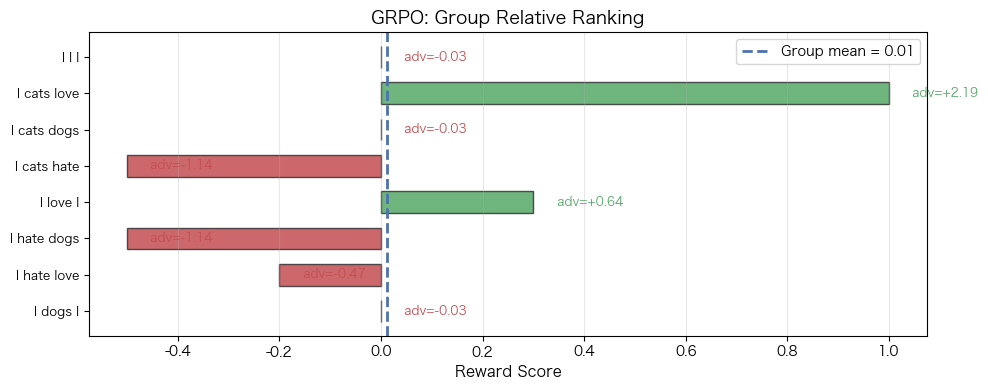

In [17]:
# ── Demonstrate group-relative advantage ──
torch.manual_seed(42)
policy = TinyLM()

# Generate a group of 8 outputs
group = policy.generate(8)
scores = reward_fn(group).numpy()
labels = [decode(s) for s in group]

print("Group of 8 generated sequences:")
for label, score in zip(labels, scores):
    print(f"  {label:20s}  reward = {score:+.2f}")

print(f"\nGroup mean = {scores.mean():.2f}")
print(f"Group std  = {scores.std():.2f}")

fig, ax = draw_group_ranking(scores, labels)
plt.show()

info_box(
    "Green bars: sequences that scored above the group mean → positive advantage "
    "(model should generate these more often).<br>"
    "Red bars: below the mean → negative advantage (generate less often).<br>"
    "No critic model needed — just compare within the group!",
    title="GRPO: Group-Relative Advantage"
)

In [18]:
# ── Train with GRPO ──
torch.manual_seed(42)
policy = TinyLM()
ref_model = deepcopy(policy)
for p in ref_model.parameters():
    p.requires_grad = False

optimizer = torch.optim.Adam(policy.parameters(), lr=3e-3)
kl_coeff = 0.15
grpo_rewards = []

for step in range(300):
    # 1. Generate a group of outputs
    group_size = 16
    seqs = policy.generate(group_size)
    rewards = reward_fn(seqs)

    # 2. Group-relative advantage (GRPO's key idea)
    advantages = (rewards - rewards.mean()) / (rewards.std() + 1e-8)

    # 3. Policy gradient with KL penalty
    new_lp = policy.log_probs_of(seqs)
    ref_lp = ref_model.log_probs_of(seqs)
    kl = (new_lp - ref_lp).mean()

    loss = -(new_lp * advantages.detach()).mean() + kl_coeff * kl

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    grpo_rewards.append(rewards.mean().item())
    if step % 60 == 0:
        print(f"Step {step:3d}  reward={rewards.mean():.3f}  kl={kl.item():.3f}")

print("\nAfter GRPO training:")
seqs = policy.generate(200)
counts = Counter(decode(s) for s in seqs)
for text, count in counts.most_common(5):
    print(f"  {text:20s}  freq={count/200:.0%}")

Step   0  reward=0.050  kl=-0.000
Step  60  reward=0.456  kl=1.831
Step 120  reward=0.956  kl=2.746


Step 180  reward=1.000  kl=3.041


Step 240  reward=1.000  kl=3.354

After GRPO training:
  I love cats           freq=85%
  I cats love           freq=14%
  I I cats              freq=0%
  I love love           freq=0%


## 算法比较

三法已悉验之，今列而较之：

In [19]:
comparison_table(
    headers=["Algorithm", "Models in Memory", "Needs Reward Model?",
             "Training Data", "Key Advantage", "Key Limitation"],
    rows=[
        ["PPO (RLHF)", "4 (actor + critic + reward + ref)",
         "Yes", "On-policy (generated)", "Most flexible, well-studied",
         "Complex, memory-hungry"],
        ["DPO", "2 (policy + ref)",
         "No", "Offline preference pairs", "Simple, stable",
         "No online exploration"],
        ["GRPO", "2 (policy + ref)",
         "No (uses verifier)", "On-policy groups", "Simple, on-policy",
         "Needs good reward/verifier"],
    ],
    title="PPO vs DPO vs GRPO"
)

Algorithm,Models in Memory,Needs Reward Model?,Training Data,Key Advantage,Key Limitation
PPO (RLHF),4 (actor + critic + reward + ref),Yes,On-policy (generated),"Most flexible, well-studied","Complex, memory-hungry"
DPO,2 (policy + ref),No,Offline preference pairs,"Simple, stable",No online exploration
GRPO,2 (policy + ref),No (uses verifier),On-policy groups,"Simple, on-policy",Needs good reward/verifier


In [20]:
# Memory comparison for a 7B model
params_7b = 7e9
bytes_per_param = 2  # fp16

model_gb = params_7b * bytes_per_param / 1e9
print(f"One 7B model in fp16: {model_gb:.1f} GB\n")

configs = [
    ("PPO (RLHF)", 4, "Actor + Critic + Reward + Reference"),
    ("DPO",        2, "Policy + Reference"),
    ("GRPO",       2, "Policy + Reference"),
]

for name, n_models, desc in configs:
    total = model_gb * n_models
    print(f"  {name:12s}  {n_models} models × {model_gb:.0f} GB = {total:.0f} GB  ({desc})")

print(f"\nPPO needs ~{4*model_gb:.0f} GB just for model weights — before optimizer states!")
print("This is why DPO and GRPO are popular: half the memory.")

One 7B model in fp16: 14.0 GB

  PPO (RLHF)    4 models × 14 GB = 56 GB  (Actor + Critic + Reward + Reference)
  DPO           2 models × 14 GB = 28 GB  (Policy + Reference)
  GRPO          2 models × 14 GB = 28 GB  (Policy + Reference)

PPO needs ~56 GB just for model weights — before optimizer states!
This is why DPO and GRPO are popular: half the memory.


## 演进与前沿

### 迄今之脉络

每一新算法，皆为解前法之困：

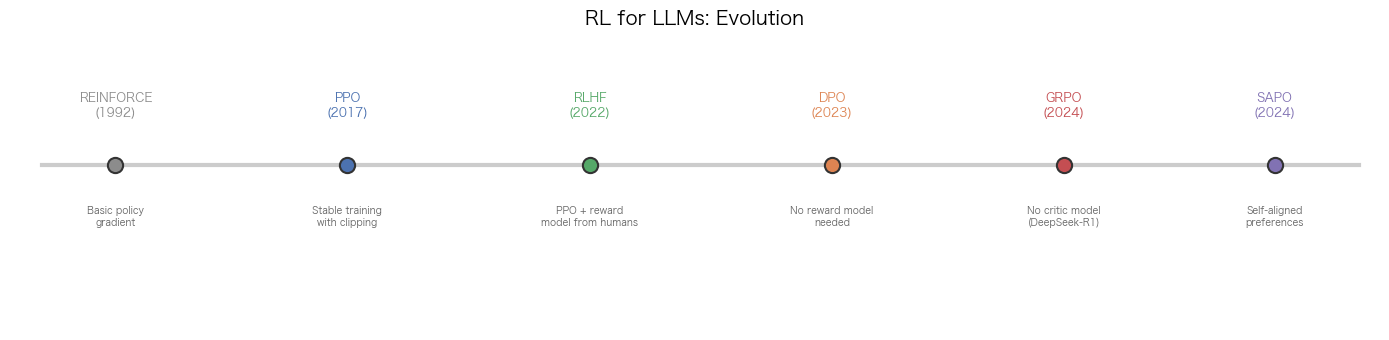

In [21]:
fig, ax = draw_method_timeline()
plt.show()

### SAPO：自对齐偏好优化（2024）

前沿更进一步：**若无需人之偏好数据，奈何？**

SAPO（自对齐偏好优化）以模型自身生成偏好对：
1. 对同一提示生成二答
2. 以简质量信号（长度、连贯、自洽）排之
3. 以 DPO 式损失训于此自生之偏好对

此成一**自我改进之环** —— 模型自举其对齐。

### 诸大模型所用何法？

| 模型 | 方法 | 要创新 |
|------|------|--------|
| ChatGPT / GPT-4 | PPO (RLHF) | 大规模 RLHF 之先驱 |
| Llama-2-Chat | PPO (RLHF) | 拒绝采样 + PPO |
| Zephyr | DPO | 证 DPO 可比肩 RLHF |
| DeepSeek-R1 | GRPO | 群组相对优势，无评论模型 |
| Qwen-2 | DPO + GRPO | 混合之法 |

## 分布式之挑战

大规模训练大语言模型时，强化学习对齐引入独特之分布式系统挑战，超乎寻常之预训练：

### 其一、多模型之编排
PPO 需四模型（参数总量约四倍）同驻 GPU 显存。即 DPO、GRPO 亦需二倍。此与预训练迥异——预训练仅一模型耳。

### 其二、生成之瓶颈
强化学习需模型**生成文本**（自回归，逐词元而出）。此远慢于预训练之前向、反向传播，常为时间之主要消耗。

### 其三、在策略数据之时效
PPO 与 GRPO 皆**在策略（on-policy）** —— 训练数据须出自*当前*模型，非存储之数据集。不可预生数据；须循环往复：生成 → 训练 → 生成 → 训练。

### GPU 分置之策

诸框架以不同分置策略解此诸难：

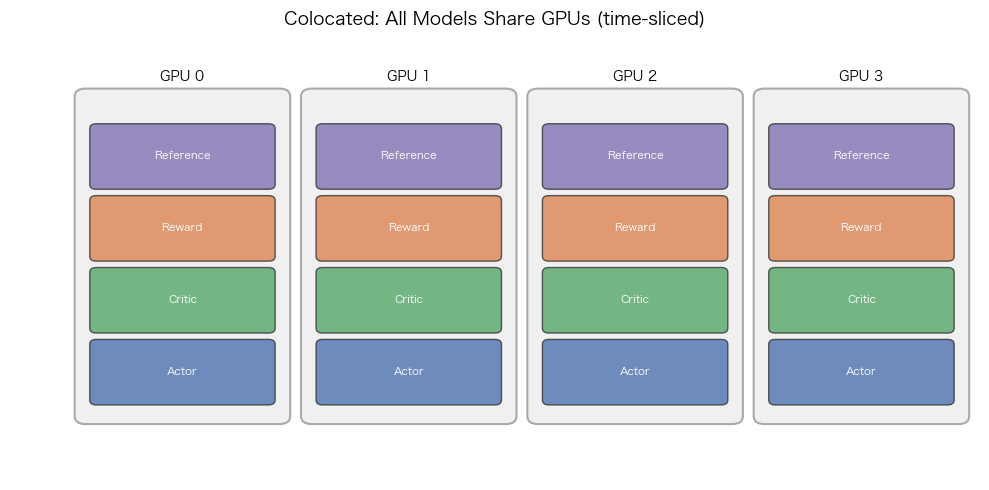

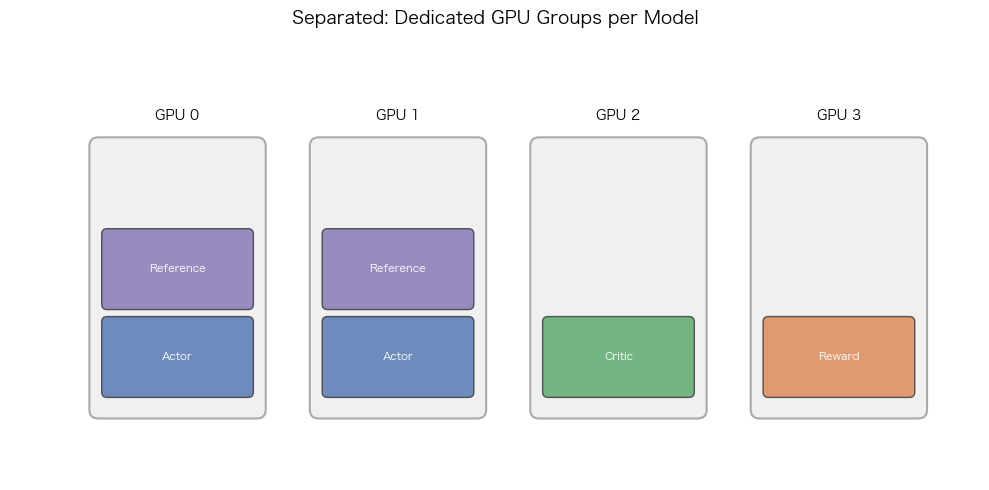

Framework,Strategy,Key Idea
DeepSpeed-Chat,Colocated → Separated,"All models on same GPUs, then offload"
OpenRLHF,Separated (Ray),"Dedicated GPU groups per model, Ray orchestration"
veRL (Volcano Engine),Hybrid SPMD,"Flexible placement, overlaps generation + training"


In [22]:
fig1, ax1 = draw_rl_gpu_placement(strategy="colocated")
plt.show()

fig2, ax2 = draw_rl_gpu_placement(strategy="separated")
plt.show()

comparison_table(
    headers=["Framework", "Strategy", "Key Idea"],
    rows=[
        ["DeepSpeed-Chat", "Colocated → Separated", "All models on same GPUs, then offload"],
        ["OpenRLHF", "Separated (Ray)", "Dedicated GPU groups per model, Ray orchestration"],
        ["veRL (Volcano Engine)", "Hybrid SPMD", "Flexible placement, overlaps generation + training"],
    ],
    title="RL Training Frameworks"
)

In [23]:
code_reference(
    code="""# OpenRLHF: Actor-Critic separated across GPU groups
class PPOTrainer:
    def __init__(self, actor, critic, reward_model, ref_model):
        # Each model can be on different GPU groups
        self.actor = ActorModelRayActor(actor, gpu_group_0)
        self.critic = CriticModelRayActor(critic, gpu_group_1)
        self.reward = RewardModelRayActor(reward_model, gpu_group_2)
        self.ref = RefModelRayActor(ref_model, gpu_group_0)  # shares with actor

    def step(self, prompts):
        # 1. Generate with actor
        sequences = self.actor.generate(prompts)
        # 2. Score with reward model
        rewards = self.reward.score(sequences)
        # 3. Compute values with critic
        values = self.critic.evaluate(sequences)
        # 4. PPO update
        self.actor.ppo_step(sequences, rewards, values)""",
    source="OpenRLHF",
    filepath="openrlhf/trainer/ppo_trainer.py"
)

## 总结与延伸阅读

### 要旨

1. **强化学习对齐**乃大语言模型训练之第三阶（继预训练与有监督微调）—— 优化人之*所好*，非人之所示
2. **策略梯度**乃核心之理：增高奖赏之输出之概率，降低奖薄者之概率
3. **PPO** 以裁剪目标与 KL 惩罚稳定训练，然需四模型驻存
4. **DPO** 直接优化偏好而去奖赏模型 —— 自四模型减至二
5. **GRPO** 以群组相对优势去评论模型 —— 更简之在策略训练（DeepSeek-R1 所用）
6. **SAPO** 更进一步：以自生之偏好实现自举对齐
7. 大规模时，分布式强化学习面临独特之挑战：多模型显存、生成瓶颈、在策略数据时效

### 演进一言以蔽之

> REINFORCE（噪杂）→ **PPO**（稳定，四模型）→ **DPO**（更简，二模型，离线）→ **GRPO**（更简，二模型，在线）→ **SAPO**（自对齐）

### 延伸阅读

**论文：**
- [PPO (Schulman et al., 2017)](https://arxiv.org/abs/1707.06347) — Proximal Policy Optimization
- [RLHF (Ouyang et al., 2022)](https://arxiv.org/abs/2203.02155) — Training language models to follow instructions with human feedback
- [DPO (Rafailov et al., 2023)](https://arxiv.org/abs/2305.18290) — Direct Preference Optimization
- [GRPO / DeepSeek-R1 (2025)](https://arxiv.org/abs/2501.12948) — DeepSeek-R1: Incentivizing Reasoning Capability in LLMs via RL
- [SAPO (2024)](https://arxiv.org/abs/2405.07863) — Self-Aligned Preference Optimization

**框架：**
- [DeepSpeed-Chat](https://github.com/microsoft/DeepSpeedExamples/tree/master/applications/DeepSpeed-Chat) — 端到端 RLHF 流水线
- [OpenRLHF](https://github.com/OpenRLHF/OpenRLHF) — 基于 Ray 之分布式 RLHF
- [veRL](https://github.com/volcengine/verl) — 火山引擎大语言模型强化学习
- [TRL](https://github.com/huggingface/trl) — Hugging Face Transformer Reinforcement Learning